# Одномерная LSTM: выбор на validation

Notebook выполняет зафиксированный grid search с checkpoint, выбирает отдельную конфигурацию для каждого тикера и сравнивает seed-ensemble с `naive_zero` и ранее выбранной ARIMA. Final test остаётся закрытым.

In [1]:
import sys
from collections.abc import Mapping
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import clear_output, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.contracts import BPS_FACTOR  # noqa: E402
from evaluation.loading import DATASET_NAME, load_processed_snapshot  # noqa: E402
from evaluation.lstm_selection import select_lstm_candidates  # noqa: E402
from evaluation.lstm_validation import CORE_TICKERS, run_lstm_grid  # noqa: E402
from evaluation.metrics import calculate_metrics  # noqa: E402
from evaluation.pipeline import build_predictions  # noqa: E402
from evaluation.walk_forward import build_walk_forward_predictions  # noqa: E402
from models.arima import ARIMAFitter  # noqa: E402
from models.lstm import LSTMTrainer, build_lstm_grid  # noqa: E402
from models.naive import NaiveModel  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
CHECKPOINT_DIR = PROJECT_ROOT / "artifacts" / "lstm_validation"
EXPECTED_RUNS = len(CORE_TICKERS) * len(build_lstm_grid()) * 10
FIXED_ARIMA_ORDERS = {
    "AAPL": (0, 0, 0),
    "JPM": (0, 0, 1),
    "SPY": (0, 0, 2),
    "XOM": (2, 0, 1),
}

## Проверка снимка и границ эксперимента

In [2]:
snapshot = load_processed_snapshot(PROJECT_ROOT / "data" / "processed")
dataset = snapshot.dataset
files = snapshot.metadata.get("files")
assert isinstance(files, Mapping)
dataset_record = files.get(DATASET_NAME)
assert isinstance(dataset_record, Mapping)
dataset_sha256 = dataset_record.get("sha256")
assert isinstance(dataset_sha256, str) and len(dataset_sha256) == 64

test_target_dates = set(dataset.loc[dataset["split"].eq("test"), "target_date"])
modeling_data = dataset.loc[
    dataset["ticker"].isin(CORE_TICKERS) & dataset["split"].isin({"train", "validation"})
].copy()
assert set(modeling_data["ticker"]) == set(CORE_TICKERS)
assert set(modeling_data["split"]) == {"train", "validation"}
assert not modeling_data["target_date"].isin(test_target_dates).any()

modeling_data.groupby(["ticker", "split"], sort=True).agg(
    observations=("target_return", "size"),
    first_target_date=("target_date", "min"),
    last_target_date=("target_date", "max"),
)

observations first_target_date last_target_date
ticker split                                                      
AAPL   train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
JPM    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
SPY    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31
XOM    train               2515        2006-01-05       2015-12-31
       validation          1006        2016-01-04       2019-12-31

## Возобновляемый grid search

Следующая ячейка выполняет до 480 двухэтапных запусков. Совместимые завершённые результаты загружаются из checkpoint. Прогресс обновляется после каждого полного запуска, а не каждой эпохи; до первого завершения ETA неизвестна. Оценка времени учитывает только новые запуски текущей сессии и может меняться между архитектурами.

In [3]:
grid_progress = {"initial_completed": 0, "started_at": perf_counter()}


def report_grid_progress(completed: int, total: int, run_id: str) -> None:
    if not run_id:
        grid_progress["initial_completed"] = completed
        grid_progress["started_at"] = perf_counter()
    elapsed = perf_counter() - grid_progress["started_at"]
    new_completed = completed - int(grid_progress["initial_completed"])
    if completed == total:
        eta = "0.0 мин"
    elif new_completed > 0:
        eta = f"{(total - completed) * elapsed / new_completed / 60:.1f} мин"
    else:
        eta = "ожидаем первый новый результат"
    clear_output(wait=True)
    print(
        f"LSTM grid: {completed}/{total} | последний: {run_id or 'checkpoint'} | "
        f"прошло {elapsed / 60:.1f} мин | ETA: {eta}"
    )


trainer = LSTMTrainer()
runs = run_lstm_grid(
    modeling_data,
    dataset_sha256,
    CHECKPOINT_DIR,
    trainer,
    progress=report_grid_progress,
)

LSTM grid: 480/480 | последний: XOM_lstm_w63_u32_d20_seed_09 | прошло 161.2 мин | ETA: 0.0 мин


In [4]:
status_summary = (
    pd.Series([run.status for run in runs], name="status")
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="runs")
)
assert len(runs) == EXPECTED_RUNS
assert sum(status_summary["runs"]) == EXPECTED_RUNS
display(status_summary)
failed_runs = pd.DataFrame(
    [
        {"run_id": run.key.run_id, "status": run.status, "error": run.error}
        for run in runs
        if run.status != "ok"
    ],
    columns=["run_id", "status", "error"],
)
if not failed_runs.empty:
    display(failed_runs)

,status,runs
0,ok,480


## Выбор конфигураций и seed-ensemble

In [5]:
baseline_predictions = (
    build_predictions(modeling_data, NaiveModel())
    .loc[lambda frame: frame["split"].eq("validation")]
    .reset_index(drop=True)
)
lstm_selection = select_lstm_candidates(runs, baseline_predictions)
lstm_predictions = lstm_selection.predictions

assert set(lstm_selection.configurations["ticker"]) == set(CORE_TICKERS)
assert lstm_selection.configurations["successful_seeds"].eq(10).all()
lstm_selection.configurations

,ticker,window,units,dropout,successful_seeds,mean_mae_bps,mean_rmse_bps,std_mae_bps,parameter_count,model
0,AAPL,5,32,0.0,10,105.844797,153.521140,0.031948,4385,lstm
1,JPM,63,16,0.2,10,92.055264,130.408463,0.195891,1169,lstm
2,SPY,21,32,0.2,10,54.361614,80.981183,0.065361,4385,lstm
3,XOM,5,16,0.2,10,83.262807,113.819642,0.095385,1169,lstm


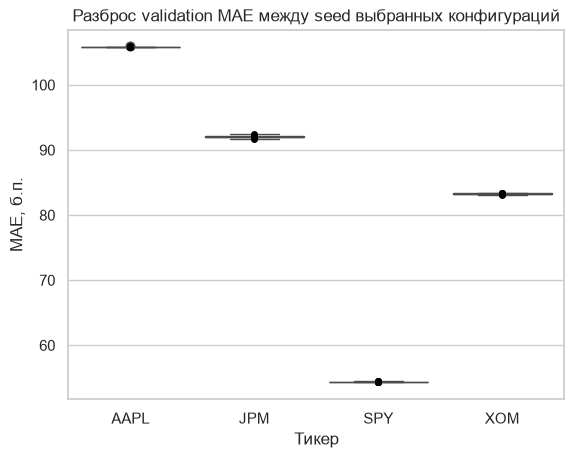

In [6]:
configuration_columns = ["ticker", "window", "units", "dropout"]
selected_seed_metrics = lstm_selection.run_metrics.merge(
    lstm_selection.configurations.loc[:, configuration_columns],
    on=configuration_columns,
    how="inner",
    validate="many_to_one",
)
assert selected_seed_metrics["status"].eq("ok").all()
assert selected_seed_metrics.groupby("ticker")["seed"].nunique().eq(10).all()
ax = sns.boxplot(data=selected_seed_metrics, x="ticker", y="mae_bps")
sns.stripplot(
    data=selected_seed_metrics, x="ticker", y="mae_bps", color="black", jitter=False, ax=ax
)
ax.set(
    title="Разброс validation MAE между seed выбранных конфигураций",
    xlabel="Тикер",
    ylabel="MAE, б.п.",
)
plt.show()

## Повторный validation-прогноз зафиксированной ARIMA

Порядки не подбираются заново, но ARIMA переобучается на каждой origin date. Этот блок тоже может выполняться долго и не имеет checkpoint. Прогресс обновляется после первого прогноза, затем каждые 25 прогнозов и в конце.

In [7]:
arima_started_at = perf_counter()


def report_arima_progress(completed: int, total: int) -> None:
    if completed not in {0, 1, total} and completed % 25 != 0:
        return
    elapsed = perf_counter() - arima_started_at
    eta = (
        f"{(total - completed) * elapsed / completed / 60:.1f} мин"
        if completed > 0
        else "ожидаем первый прогноз"
    )
    clear_output(wait=True)
    print(f"ARIMA: {completed}/{total} | прошло {elapsed / 60:.1f} мин | ETA: {eta}")


arima_fitter = ARIMAFitter(FIXED_ARIMA_ORDERS, model_name="arima")
report_arima_progress(0, len(baseline_predictions))
arima_predictions = build_walk_forward_predictions(
    modeling_data, arima_fitter, progress=report_arima_progress
)
assert arima_predictions["model"].eq("arima").all()

ARIMA: 4024/4024 | прошло 12.4 мин | ETA: 0.0 мин


## Проверка выравнивания и validation-метрики

In [8]:
comparison = pd.concat(
    [baseline_predictions, arima_predictions, lstm_predictions],
    ignore_index=True,
)
assert comparison["split"].eq("validation").all()
assert not comparison["target_date"].isin(test_target_dates).any()
assert set(comparison["model"]) == {"lstm", "arima", "naive_zero"}
assert set(comparison["ticker"]) == set(CORE_TICKERS)

alignment_columns = ["ticker", "date", "target_date", "split", "actual_return"]
baseline_keys = (
    baseline_predictions.loc[:, alignment_columns]
    .sort_values(alignment_columns[:4])
    .reset_index(drop=True)
)
for model_name in ("arima", "lstm"):
    model_keys = (
        comparison.loc[comparison["model"].eq(model_name), alignment_columns]
        .sort_values(alignment_columns[:4])
        .reset_index(drop=True)
    )
    pd.testing.assert_frame_equal(model_keys, baseline_keys)

observation_counts = comparison.groupby(["model", "ticker"]).size().unstack(0)
assert observation_counts.nunique(axis=1).eq(1).all()
observation_counts

model,arima,lstm,naive_zero
ticker,,,
AAPL,1006,1006,1006
JPM,1006,1006,1006
SPY,1006,1006,1006
XOM,1006,1006,1006


In [9]:
validation_metrics = calculate_metrics(comparison)
validation_metrics.round(
    {
        "mae_bps": 3,
        "rmse_bps": 3,
        "rel_mae": 4,
        "oos_r2": 4,
        "directional_accuracy": 4,
    }
)

,split,ticker,model,observations,mae_bps,rmse_bps,rel_mae,oos_r2,directional_accuracy
0,validation,AAPL,arima,1006,105.899,153.525,0.9960,0.0046,0.5437
1,validation,JPM,arima,1006,92.351,130.760,1.0051,-0.0062,0.4970
2,validation,SPY,arima,1006,54.813,81.319,0.9996,0.0016,0.5249
3,validation,XOM,arima,1006,84.194,115.552,1.0099,-0.0309,0.5109
4,validation,ALL,arima,4024,84.314,123.119,1.0025,-0.0064,0.5191
5,validation,AAPL,lstm,1006,105.828,153.503,0.9953,0.0049,0.5437
6,validation,JPM,lstm,1006,91.975,130.319,1.0011,0.0005,0.5050
7,validation,SPY,lstm,1006,54.307,80.923,0.9904,0.0113,0.5557
8,validation,XOM,lstm,1006,83.243,113.783,0.9985,0.0004,0.5199
9,validation,ALL,lstm,4024,83.838,122.517,0.9969,0.0034,0.5311


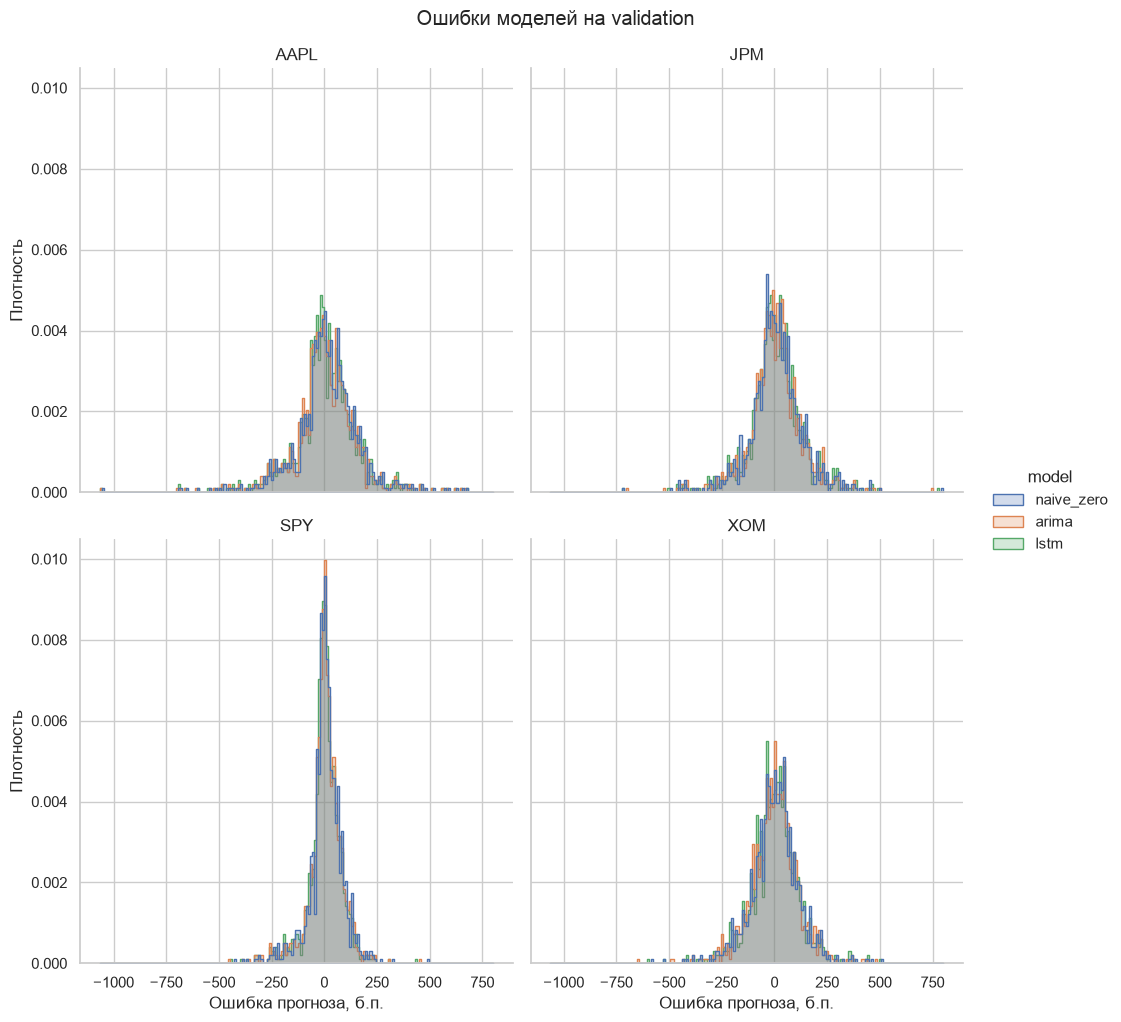

In [10]:
errors = comparison.assign(
    error_bps=(comparison["actual_return"] - comparison["predicted_return"]) * BPS_FACTOR
)
grid = sns.displot(
    data=errors,
    x="error_bps",
    hue="model",
    col="ticker",
    col_wrap=2,
    kind="hist",
    element="step",
    stat="density",
    common_norm=False,
)
grid.set_axis_labels("Ошибка прогноза, б.п.", "Плотность")
grid.set_titles("{col_name}")
grid.figure.suptitle("Ошибки моделей на validation", y=1.02)
plt.show()

## Ограничения интерпретации

- Validation использована для выбора архитектуры LSTM, поэтому показанные метрики не являются независимой оценкой обобщения.
- Сравнение относится к одномерной LSTM только на прошлых доходностях.
- LSTM использует фиксированные train-веса и scaler, ARIMA переобучается ежедневно: сравниваются модели вместе с разными процедурами обновления.
- Различия seed отражают чувствительность к инициализации; итоговая модель использует их средний прогноз.
- Плохой результат LSTM не является основанием менять grid после просмотра метрик.
- Final test не открывался и должен быть использован только после фиксации всех моделей.